# Compressor polynomial model used in the model


### import

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from unsflow.utils.plot_styles import *

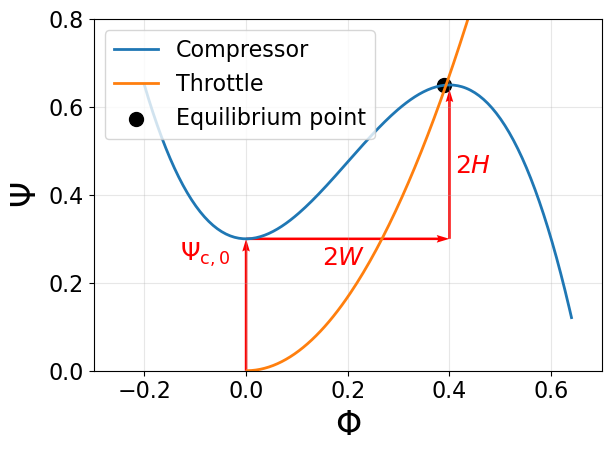

In [3]:
# --- Parameters ---
W = 0.2       # Flow coefficient at the reference point (sets horizontal scaling)
H = 0.175       # Peak-to-valley amplitude of the characteristic (pressure rise capability)
psi_c0 = 0.3   # Baseline (offset) of the characteristic (minimum pressure rise)

# --- Define the compressor characteristic function ---
def psi_c(phi):
    """
    Computes the compressor characteristic ψ_c(φ):
    ψ_c(φ) = ψ_c0 + H * [1 + 1.5*(φ/W - 1) - 0.5*(φ/W - 1)^3]
    where:
      - φ : nondimensional flow coefficient
      - W : reference flow coefficient (scales the cubic)
      - H : amplitude of the characteristic curve
      - ψ_c0 : offset of the curve
    """
    return psi_c0 + H * (1 + 1.5*(phi/W - 1) - 0.5*(phi/W - 1)**3)

# --- Generate data ---
phi = np.linspace(-W, 3.2*W, 200)   # range of flow coefficients around the operating region
psi = psi_c(phi)

# --- Plot ---
plt.figure()
plt.plot(phi, psi, linewidth=2, label='Compressor')
plt.plot(phi[phi>0], 4.2*phi[phi>0]**2, linewidth=2, label='Throttle')
plt.scatter(0.39, 0.65, color='k', s=100, label='Equilibrium point')

plt.text(-0.13, 0.25, 
         r'$\Psi_{\rm c,0}$', 
         fontsize=18, 
         color='red')
plt.quiver(0.0, 0.0, 0.0, psi_c0, angles='xy', scale_units='xy', scale=1, color='red',width=0.005)

plt.text(0.15, 0.24, 
         r'$2W$', 
         fontsize=18, 
         color='red')
plt.quiver(0.0, psi_c0, 2*W, 0, angles='xy', scale_units='xy', scale=1, color='red',width=0.005)

plt.text(0.41, 0.45, 
         r'$2H$', 
         fontsize=18, 
         color='red')
plt.quiver(2*W, psi_c0, 0, 2*H-0.01, angles='xy', scale_units='xy', scale=1, color='red', width=0.005)

plt.xlabel(r'$\Phi$')
plt.ylabel(r'$\Psi$')
plt.xlim([-0.3, 0.7])
plt.ylim([0, 0.8])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('compressor_axisymmetric_cubic_model.pdf', bbox_inches='tight')